In [ ]:
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.io import fits
from astropy.convolution import convolve
from astropy.modeling.models import Sersic2D
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
import astropy.units as u
from astropy.constants import c
from reproject import reproject_interp
from scipy.optimize import minimize, least_squares
from scipy.signal import fftconvolve, convolve2d
import dynesty
import dynesty.pool as dypool
from dynesty import plotting as dyplot
import dynesty.utils as dyutil
import pickle
import corner
from cmcrameri import cm
from multiprocessing import Pool
import importlib
import warnings
warnings.simplefilter('ignore', DeprecationWarning)
%matplotlib inline
# seed the random number generator
rstate = np.random.default_rng(111)

from glint.beam import cleanbeam_from_header
import glint.lensing as ls
from glint.context import ImageContext
from glint.forward import forward_model_3D_image
from glint.inference import run_emcee
from glint.plotstyle import set_my_plot_style
from params_kinematics import param_names, param_table

In [2]:
set_my_plot_style()

In [3]:
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

## Data

Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


hst peak: 8.0, 17.0 pix, corresponding to 0.160, 0.340 arcsec from the center
hst centroid: 4.7, 3.5 pix, corresponding to 0.093, 0.070 arcsec from the center
hst gaussian fit: 10.8, 14.5 pix, corresponding to 0.217, 0.290 arcsec from the center
Number of pixels in the mask: 26404
Number of channels: 12
Number of pixels in image plane: 201 x 201
Pixel scale in image plane: 0.02 arcsec/pixel


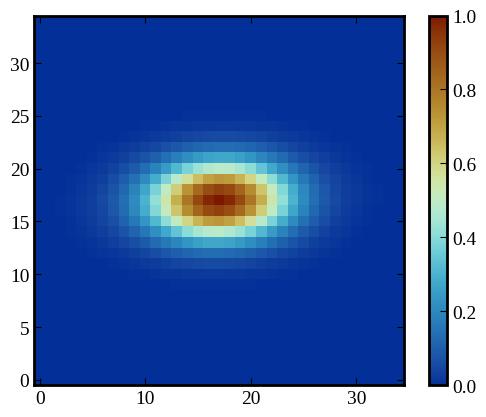

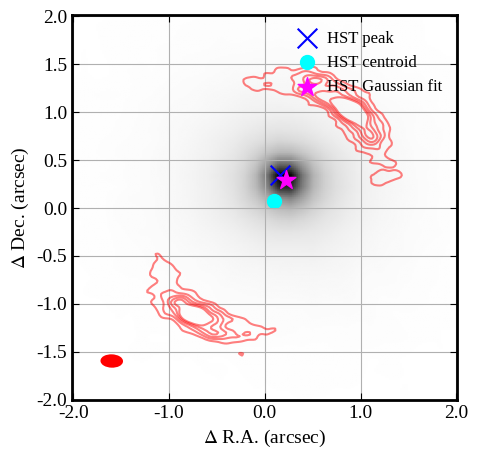

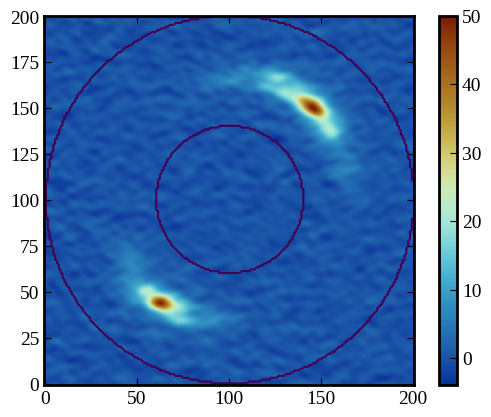

In [4]:
# image data
data_dir = Path("./data").resolve()
data_dir.exists()

obsfits   = str(data_dir / "B6_concat_CII_dv50km_rob-0.5_clean.image.pbcor.cutout.-250+300km.fits")
noisefits = str(data_dir / "B6_concat_CII_dv50km_rob-0.5_clean.noise.pbcor.cutout.-250+300km.fits")

obsdata, obsheader = fits.getdata(obsfits, header=True)
noisedata = fits.getdata(noisefits)
noisedata_inv = 1/noisedata
BMAJ, BMIN, BPA, CDELT = obsheader['BMAJ'], obsheader['BMIN'], obsheader['BPA'], obsheader['CDELT2']

beam = cleanbeam_from_header(35, obsheader)
plt.imshow(beam, origin="lower", cmap=cm.roma_r)
plt.colorbar()


#### Continuum data for overlay ####
contfits   = str(data_dir / "B6_concat_cont_rob-0.5_clean.image.pbcor.cutout.fits")
contnoisefits = str(data_dir / "B6_concat_cont_rob-0.5_clean.noise.pbcor.cutout.fits")

contdata, contheader = fits.getdata(contfits, header=True)
contnoisedata = fits.getdata(contnoisefits)
####

# あとは同じ
hst_fits = str(data_dir / "hst_skycell-p1356x14y05_wfc3_ir_f125w_coarse-all_drz.fits")
hst_data, hst_header = fits.getdata(hst_fits, header=True)
hst_wcs = WCS(hst_header)

# reproject to ALMA
hst_on_alma, footprint = reproject_interp((hst_data, hst_wcs), WCS(contheader, naxis=2), shape_out=contdata.shape)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(hst_on_alma, origin='lower', cmap='gray_r')
ax.contour(contdata/contnoisedata, levels=[4,8,12,16,20], colors='red', alpha=0.5)

# 画像の中心
ny, nx = contdata.shape
x0 = (nx - 1) / 2
y0 = (ny - 1) / 2
pixscale_as = abs(obsheader['CDELT2'] * 3600) # arcsec/pix
def format_func_x(x_pix, _):
    return f"{(x_pix - x0) * pixscale_as:.1f}"
def format_func_y(y_pix, _):
    return f"{(y_pix - y0) * pixscale_as:.1f}"
from matplotlib.ticker import FuncFormatter
ax.xaxis.set_major_formatter(FuncFormatter(format_func_x))
ax.yaxis.set_major_formatter(FuncFormatter(format_func_y))

# psfサイズをimage planeの左下に楕円として表示
xy_beam = (0.10*nx, 0.10*ny)
ellipse = Ellipse(xy=xy_beam, width=BMAJ/CDELT, height=BMIN/CDELT, angle=BPA+90, edgecolor='red', facecolor='red', lw=1.5)
ax.add_patch(ellipse)
ax.grid()

# HST peak
hst_peak = np.unravel_index(np.nanargmax(hst_on_alma), hst_on_alma.shape)
ax.scatter(hst_peak[1], hst_peak[0], marker='x', color='blue', s=200, label='HST peak')

# HST centroid
from photutils.centroids import centroid_com
y_com, x_com = centroid_com(hst_on_alma)
ax.scatter(x_com, y_com, marker='o', color='cyan', s=100, label='HST centroid')

# HST gaussian fit
def gauss2d(p, x, y):
    A, x0, y0, sx, sy, rho, c = p
    # 相関rho入り楕円ガウス：必要なければ rho=0 に固定
    X = (x - x0); Y = (y - y0)
    z = (X/sx)**2 + (Y/sy)**2 - 2*rho*X*Y/(sx*sy)
    return A*np.exp(-0.5/(1-rho**2) * z) + c
ny, nx = hst_on_alma.shape
yy, xx = np.indices((ny, nx))
p0 = [hst_on_alma.max(), x_com, y_com, 3.0, 3.0, 0.0, 0.0]
use = np.isfinite(hst_on_alma)
def resid(p): return (gauss2d(p, xx[use], yy[use]) - hst_on_alma[use])
res = least_squares(resid, p0, bounds=([0,0,0,0.5,0.5,-0.5,-np.inf],
                                       [np.inf,nx,ny,50,50,0.5,np.inf]))
A,x0_g,y0_g,sx,sy,rho,c = res.x
ax.scatter(x0_g, y0_g, marker='*', color='magenta', s=200, label='HST Gaussian fit')

ax.set_xlabel(r"$\Delta$ R.A. (arcsec)", fontsize=14)
ax.set_ylabel(r"$\Delta$ Dec. (arcsec)", fontsize=14)
ax.legend(fontsize=12)
print(f"hst peak: {hst_peak[1]-x0:.1f}, {hst_peak[0]-y0:.1f} pix, corresponding to {((hst_peak[1]-x0)*pixscale_as):.3f}, {((hst_peak[0]-y0)*pixscale_as):.3f} arcsec from the center")
print(f"hst centroid: {x_com-x0:.1f}, {y_com-y0:.1f} pix, corresponding to {((x_com-x0)*pixscale_as):.3f}, {((y_com-y0)*pixscale_as):.3f} arcsec from the center")
print(f"hst gaussian fit: {x0_g-x0:.1f}, {y0_g-y0:.1f} pix, corresponding to {((x0_g-x0)*pixscale_as):.3f}, {((y0_g-y0)*pixscale_as):.3f} arcsec from the center")

x0_l = (x0_g-x0)*pixscale_as
y0_l = (y0_g-y0)*pixscale_as


# mask definition
maskdata = np.zeros(contdata.shape).astype(bool)

# RMS基準にマスクを定義する場合
# thresh = 2
# maskdata[obsdata*noisedata_inv > thresh] = True

# 固定マスクを使う場合
# 円環マスク
r_inner = 0.8 # arcsec
r_outer = 2.0 # arcsec
y, x = np.indices(contdata.shape)
x_center = contdata.shape[1] / 2
y_center = contdata.shape[0] / 2
r = np.sqrt((x - x_center)**2 + (y - y_center)**2) * np.abs(CDELT) * 3600
maskdata[(r >= r_inner) & (r <= r_outer)] = True


Npix = np.nansum(maskdata)
print(f"Number of pixels in the mask: {Npix}")

# mask
# obsdata[maskdata==0] = np.nan
# noisedata_inv[maskdata==0] = np.nan

fig, ax = plt.subplots()
im = ax.imshow(contdata/contnoisedata, origin="lower", cmap=cm.roma_r)
ax.contour(maskdata)
fig.colorbar(im, ax=ax)



# source plane grid
ny_src, nx_src = 200, 200
pixsize_src = 0.005 # arcsec
x0_src, y0_src = 0.0, 0.0
xx_src, yy_src = ls.make_grid_arcsec(nx=nx_src, ny=ny_src, pixscale_arcsec=pixsize_src, x0_arcsec=x0_src, y0_arcsec=y0_src)

# image plane grid
nchan, ny_img, nx_img = obsdata.shape
pixsize_img = (np.abs(obsheader['CDELT2'])*3600).round(5)
print(f"Number of channels: {nchan}")
print(f"Number of pixels in image plane: {nx_img} x {ny_img}")
print(f"Pixel scale in image plane: {pixsize_img} arcsec/pixel")
x0_img, y0_img = 0.0, 0.0
xx_img, yy_img = ls.make_grid_arcsec(nx=nx_img, ny=ny_img, pixscale_arcsec=pixsize_img, x0_arcsec=x0_img, y0_arcsec=y0_img)

radius = np.arange(0, 0.8+1e-6, 0.01) # 0含める

spec_res_sgm_kms = 50 / (2 * np.sqrt(2 * np.log(2)))  # 50 km/s channel width -> sigma


In [5]:
from astropy.constants import c
# 周波数方向の情報

# model作成時は速度で指定
vchan_kms = np.arange(-250, 301, 50)

# [CII]158を想定
REST_FREQ_CII = 1900.5369 * u.GHz
z = 6.024
OBS_FREQ_CII = REST_FREQ_CII / (1 + z)

# Transform velocity channels to frequency channels
# V/c = -dnu/f --> dnu = - (V/c) * f --> nu = f + dnu = f * (1 - V/c)
fchan_GHz = (OBS_FREQ_CII * (1 - vchan_kms / c.to(u.km / u.s).value)).to(u.GHz).value
print(fchan_GHz)

f0 = fchan_GHz[0]
df = np.mean(np.diff(fchan_GHz))
print(f"f0: {f0} GHz, df: {df} GHz, RESTFRQ: {OBS_FREQ_CII.to(u.GHz).value} GHz")

[270.80321429 270.75808681 270.71295933 270.66783184 270.62270436
 270.57757688 270.5324494  270.48732191 270.44219443 270.39706695
 270.35193947 270.30681199]
f0: 270.80321429080266 GHz, df: -0.045127482306316906 GHz, RESTFRQ: 270.5775768792711 GHz


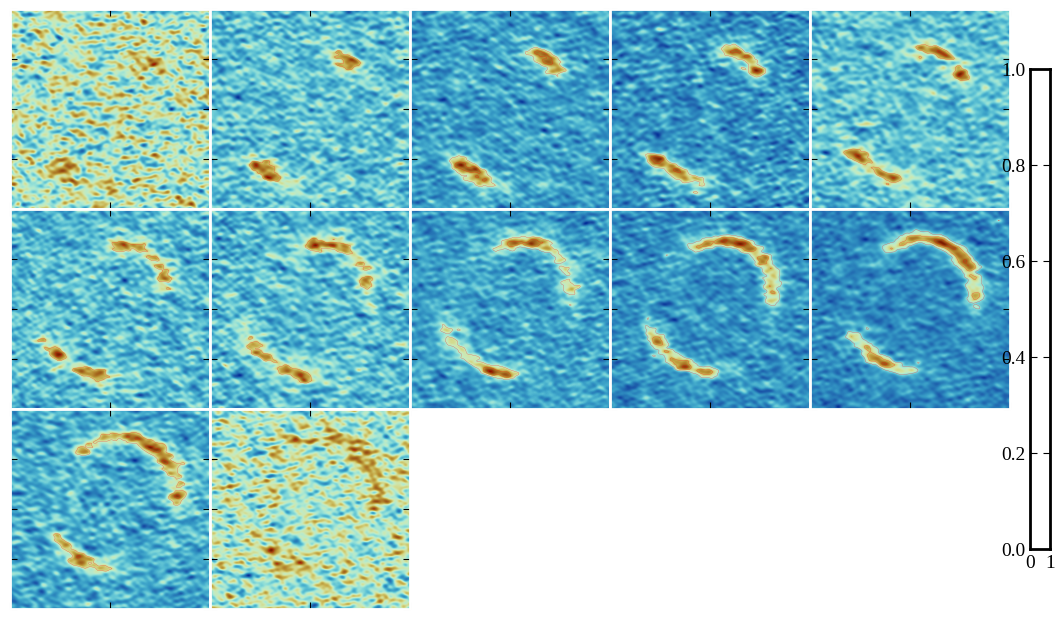

In [6]:
# plot channel maps
n_cols = 5
n_chan = obsdata.shape[0]
n_rows = int(np.ceil(n_chan / n_cols))

start = 0

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(2*n_cols, 2*n_rows))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0.0, hspace=0.0)
for i in range(n_rows * n_cols):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col]
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.spines['bottom'].set_color("white")
    ax.spines['top'].set_color("white")
    ax.spines['right'].set_color("white")
    ax.spines['left'].set_color("white")
    if i < n_chan:
        ax.imshow(obsdata[start+i], cmap=cm.roma_r, origin="lower")#, vmin=-2*rms, vmax=10*rms)
        ax.contour(obsdata[start+i]/noisedata[start+i], levels=[4, 8, 12, 16, 32], colors='red', alpha=0.7, linewidths=0.2)
        
        # ax.annotate(f"{int(vel_start+dv*i)}km/s", xy=(0.25, 0.87), xytext=(0, 0), color='white', xycoords='axes fraction', textcoords='offset points',weight='bold', ha='center', va='baseline', fontsize=25)
        # ellipse = Ellipse(xy=(0,0), width=BMAJ, height=BMIN, angle=BPA+90.,edgecolor='none', fc='white', lw=0.5)  # must be define any time
        # ax.add_patch(ellipse)
    
    # if i==0:
    #     size = 1/pix
    #     fontprops = fm.FontProperties(size=40)
    #     scalebar = AnchoredSizeBar(ax.transData,
    #                             size, r'1$^{\prime\prime}$', 'lower right',
    #                             pad=0.3,
    #                             sep=5,
    #                             color='white',
    #                             frameon=False,
    #                             size_vertical=2,
    #                             fontproperties=fontprops)
    #     ax.add_artist(scalebar)
    
    if i >= n_chan:
        ax.axis('off')

# 全体のカラーバー
cbar_ax = fig.add_axes([1.02, 0.1, 0.02, 0.8])  # [left, bottom, width, height]
# norm = plt.Normalize(vmin=-2*rms, vmax=10*rms)
# cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cm.roma_r), cax=cbar_ax)

## Common setting

In [7]:
ctx = ImageContext(
    xx_img = xx_img,
    yy_img = yy_img,
    xx_src = xx_src,
    yy_src = yy_src,
    pixsize_img = pixsize_img,
    pixsize_src = pixsize_src,
    x0_src = x0_src,
    y0_src = y0_src,
    x0_l = x0_l,
    y0_l = y0_l,
    vchan_kms = vchan_kms,
    spec_res_sgm_kms = spec_res_sgm_kms,
    radius_arcsec = radius,
    beam = beam
)

In [8]:
x0 = param_table[:,0]
lb = param_table[:,1]
ub = param_table[:,2]
ndim = len(lb)

## fitting

In [9]:
from glint.inference import run_least_squares

dof = np.sum(maskdata) * obsdata.shape[0]  # number of pixels in the mask * number of channels
dof_inv = 1/dof

# def residual(theta):
#     model = forward_model_3D_image(theta, ctx)[2]
#     diff = (obsdata - model) * noisedata_inv
#     chi2 = np.sum(diff[:, maskdata]**2) * dof_inv
#     return chi2

mask_flat = maskdata.ravel()
def residual_vec(theta):
    model = forward_model_3D_image(theta, ctx)[2]          # (nchan, ny, nx)
    r = (obsdata - model) * noisedata_inv                  # 同shape
    r = r.reshape(r.shape[0], -1)[:, mask_flat]            # (nchan, Nmask)
    return r.ravel()                                       # (nchan*Nmask,)


result = run_least_squares(residual_vec, x0, lb, ub)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.2394e+07                                    3.27e+07    
       1              2         2.5311e+06      9.86e+06       1.12e+01       5.90e+06    
       2              3         6.3515e+05      1.90e+06       1.28e+01       1.33e+06    
       3              4         2.9117e+05      3.44e+05       1.47e+01       2.90e+05    
       4              5         2.2165e+05      6.95e+04       1.77e+01       6.01e+05    
       5              6         2.1838e+05      3.28e+03       3.49e+01       3.91e+06    
       6              7         1.9434e+05      2.40e+04       9.90e+00       1.42e+04    
       7              8         1.9184e+05      2.50e+03       2.68e+01       1.27e+04    
       8              9         1.8983e+05      2.01e+03       2.67e+01       1.98e+04    
       9             10         1.8834e+05      1.49e+03       1.12e+01       9.35e+03    

In [10]:
best_fit = result.x

print("Best-fit parameters:")
for name, val in zip(param_names, best_fit):
    print(f"{name}: {val:.4f}")

Best-fit parameters:
x_s: 0.0320
y_s: 0.0266
F_0: 0.6832
inc_deg: 17.6911
pa_deg: 57.1484
r_scale: 0.1221
v_c: 499.8930
r_turn: 0.2040
gamma_curve: 1.5373
sigma_0: 75.5528
r_sigma: 0.8000
vsys_kms: 19.1111
b: 1.2680
q_l: 0.9189
pa_l: 0.0000
log_gamma: -1.1929
pa_gamma: 0.8822


Saved to ./figure/rotation_curve_fit_G09_lens_fix.pdf


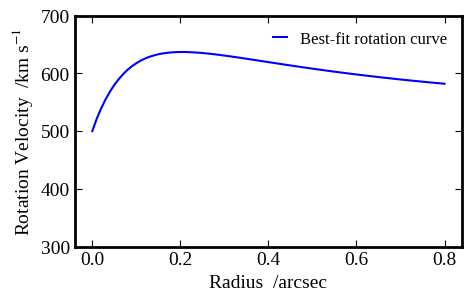

In [11]:
# rotation curve
from glint.source import Vrot_Courteau1997

radius_rc = np.arange(0, 0.8+1e-6, 0.01) # 0含める
vrot_bestfit = Vrot_Courteau1997(r=radius_rc, v_c=best_fit[6], r_turn=best_fit[7], gamma=best_fit[8], beta=1.0)
 

fig, ax = plt.subplots(figsize=(5,3))
ax.plot(radius_rc, vrot_bestfit, color='blue', label='Best-fit rotation curve')
ax.set_xlabel('Radius  /arcsec', fontsize=14)
ax.set_ylabel(r'Rotation Velocity  /km s$^{-1}$', fontsize=14)
ax.legend(fontsize=12)
ax.set_ylim(300, 700)
fig.savefig("./figure/rotation_curve_fit_G09_lens_fix.pdf", dpi=200, bbox_inches="tight")
print("Saved to ./figure/rotation_curve_fit_G09_lens_fix.pdf")
plt.show()

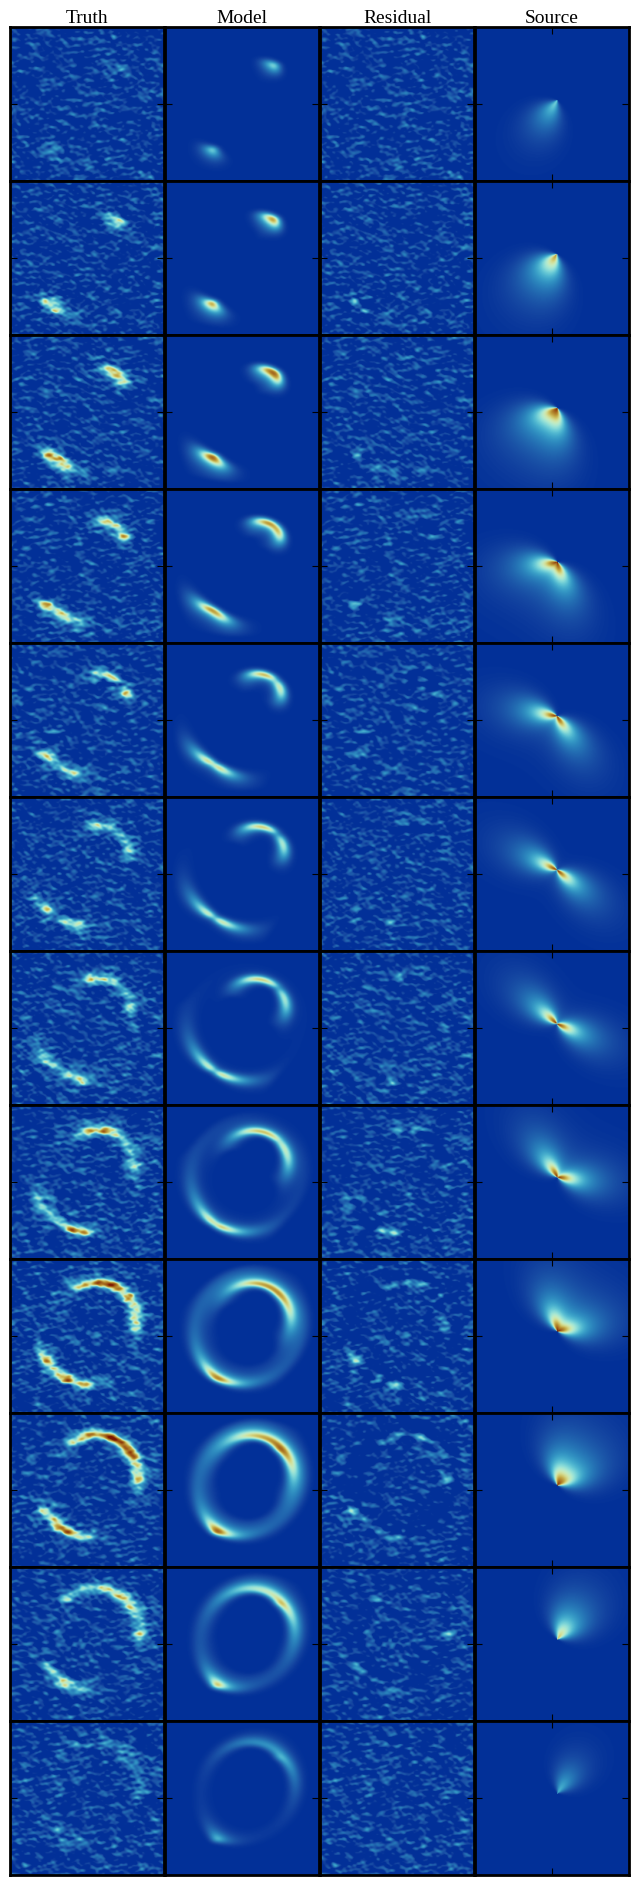

In [13]:
# model with best-fit parameters
best_source, best_lensed_cube, best_lensed_cube_conv = forward_model_3D_image(best_fit, ctx)

# Plot cube for each channel
# Some settings for plotting
vmax = np.nanmax(obsdata) * 0.9
width = 2
titles = ["Truth", "Model", "Residual", "Source"]


fig, axes = plt.subplots(nchan, ncols=4, figsize=(width*4, width*nchan))
fig.subplots_adjust(wspace=0., hspace=0.0)
for i in range(nchan):
    im0 = axes[i, 0].imshow(obsdata[i], cmap=cm.roma_r, origin="lower", vmin=0, vmax=vmax)
    # axes[i, 0].contour(obsdata[i]/noisedata[i], levels=[8,16,32], colors='black', linewidths=1.0)
    im1 = axes[i, 1].imshow(best_lensed_cube_conv[i], cmap=cm.roma_r, origin="lower", vmin=0, vmax=vmax)
    im2 = axes[i, 2].imshow((obsdata[i] - best_lensed_cube_conv[i]), cmap=cm.roma_r, origin="lower", vmin=0, vmax=vmax)
    # im2 = axes[i, 2].imshow((obsdata[i] - best_lensed_cube_conv[i]) / noisedata[i], cmap=cm.roma_r, origin="lower", vmin=-3, vmax=3)
    im3 = axes[i, 3].imshow(best_source[i], cmap=cm.roma_r, origin="lower", vmin=0, vmax=np.nanmax(best_source))

    if i==0:
        for j in range(4):
            axes[i, j].set_title(titles[j], fontsize=14, pad=-2)
    for j in range(4):
        # divider = make_axes_locatable(axes[i,j])
        # cax = divider.append_axes("right", size="5%", pad=0.)
        # fig.colorbar([im0, im1, im2, im3][j], cax=cax)
        axes[i, j].set_xticklabels([])
        axes[i, j].set_yticklabels([])

    
# fig.savefig("./figure/channel_maps_fit_G09_lens_fix.pdf", dpi=200, bbox_inches="tight")
# print("Saved to ./figure/channel_maps_fit_G09_lens_fix.pdf")
# plt.tight_layout()

In [14]:
from glint.inference import logprior_box


def loglike(theta):
    model = forward_model_3D_image(theta, ctx)[2]
    diff = (obsdata - model) * noisedata_inv
    chi2 = np.sum(diff[:, maskdata]**2)
    return -0.5 * chi2


def logprob(theta):
    lp = logprior_box(theta, lb, ub)
    if not np.isfinite(lp):
        return -np.inf
    ll = loglike(theta)
    # if not np.isfinite(ll):
    #     return -np.inf
    return lp + ll

In [15]:
chain, logprob, sampler = run_emcee(logprob_fn=logprob, x0=best_fit, lb=lb, ub=ub, nwalkers=4*len(lb), burnin=2000, production=10000, ncpu=24, init_frac=0.2, skip_initial_state_check=False)


savename = f"./mcmc_chain_G09_cube_image.npz"
np.savez(savename,
         chain=chain,
         logprob=logprob,
         param_names=param_names)

print(f"MCMC chain saved to {savename}.")

[init] min std over dims = 1.081e-01, median std = 1.682e-01
Running burn-in with 24 CPUs...


100%|██████████| 2000/2000 [08:24<00:00,  3.96it/s]


[burnin] acceptance mean = 0.385
[burnin] min std over dims = 1.353e-04, median std = 1.697e-03
Running production with 24 CPUs...


100%|██████████| 10000/10000 [34:11<00:00,  4.87it/s]



===== MCMC summary =====
steps (production): 10000 | walkers: 68 | ndim: 17
acceptance: mean=0.261, median=0.261, min=0.245, max=0.278
logprob (last step): finite fraction=1.000, median=-187011.992, max=-187007.234
worst 5 walkers (by last logprob): [43, 0, 39, 61, 26]
best  5 walkers (by last logprob): [62, 7, 2, 52, 20]
stationarity (|Δmean|/std in last half): median=7.81, max=182.96
autocorr time tau: median=1126.5, max=1328.3
ESS: median=604, min=512
N/tau: median=8.9, min=7.5
===== end summary =====

MCMC chain saved to ./mcmc_chain_G09_cube_image.npz.


## Corner plot

Loaded chain:
 chain shape: (10000, 68, 17)
 logprob shape: (10000, 68)
 ndim: 17

Flattened chain shape: (680000, 17)


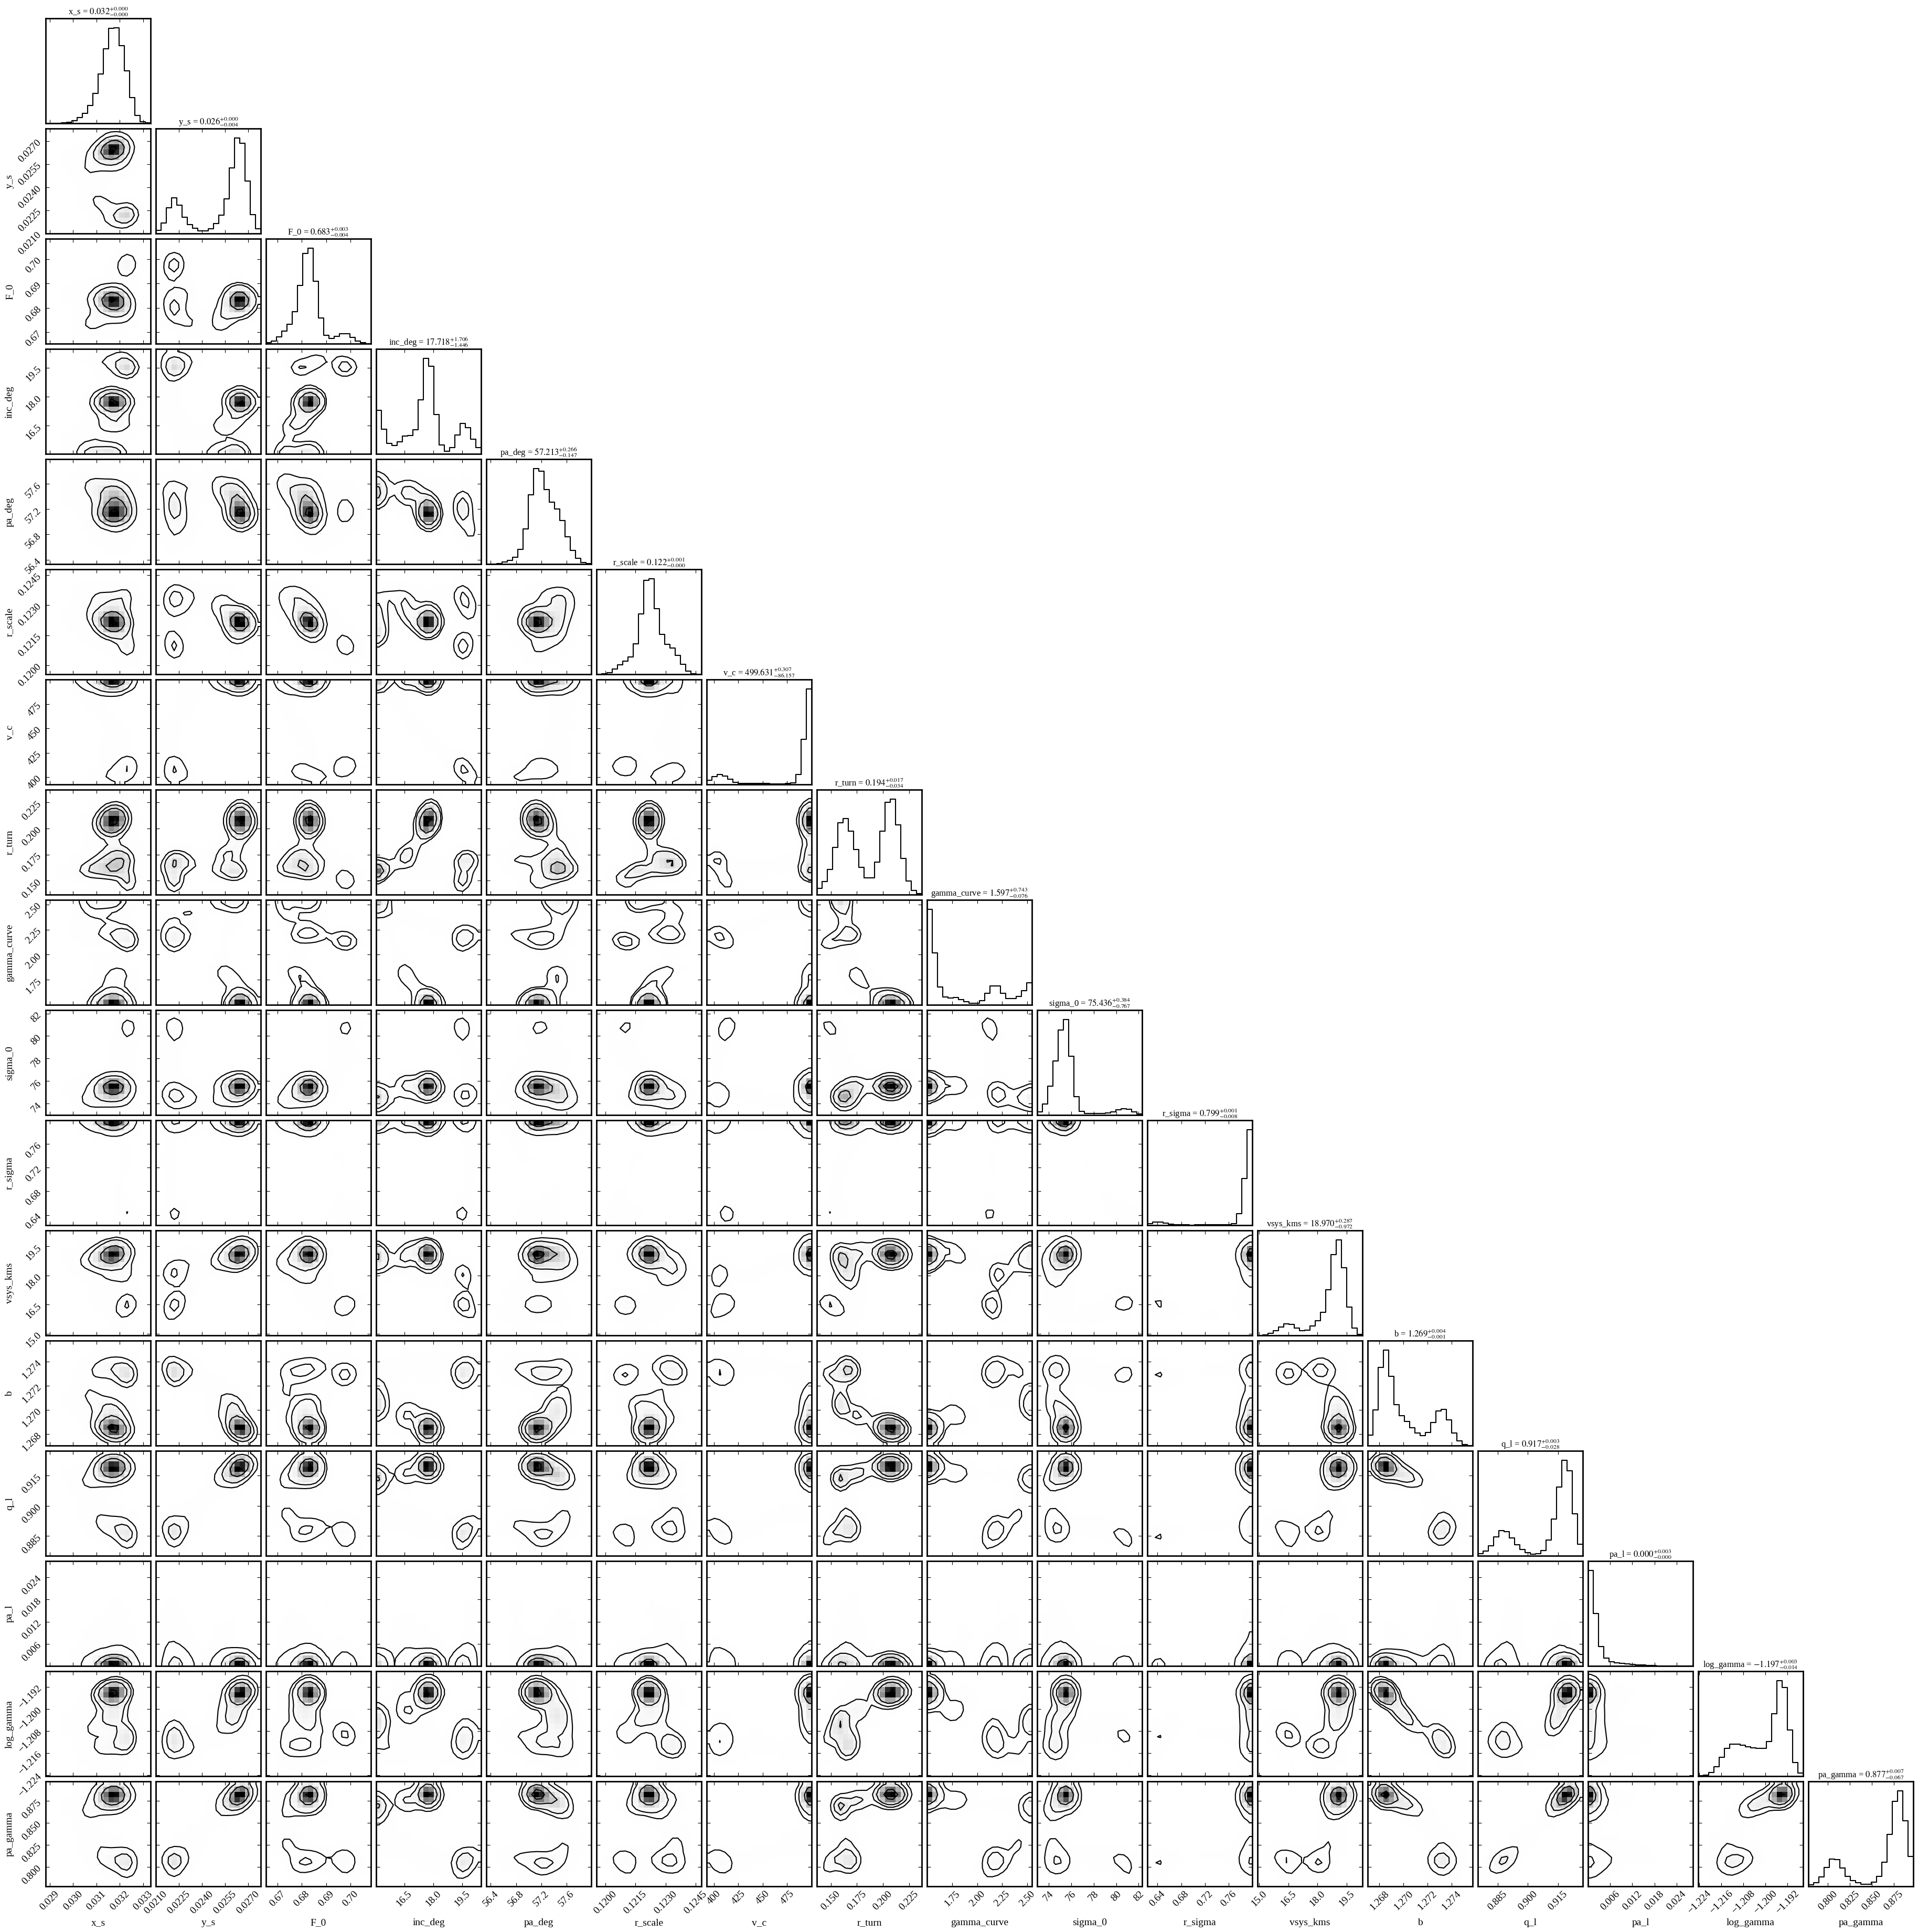


Saved corner plot: ./figure/corner_G09_lens_fix.pdf

Best-fit parameters
x_s           best=    0.0317
y_s           best=    0.0266
F_0           best=    0.6838
inc_deg       best=   17.7664
pa_deg        best=   57.0865
r_scale       best=    0.1221
v_c           best=  499.9681
r_turn        best=    0.2084
gamma_curve   best=    1.5241
sigma_0       best=   75.6156
r_sigma       best=    0.7999
vsys_kms      best=   19.0654
b             best=    1.2684
q_l           best=    0.9198
pa_l          best=    0.0001
log_gamma     best=   -1.1932
pa_gamma      best=    0.8819


In [16]:
from unicodedata import name

import numpy as np
import corner
import matplotlib.pyplot as plt

# ===============================
# Load saved chain
# ===============================

savename = f"./mcmc_chain_G09_cube_image.npz"
npzfile = np.load(savename, allow_pickle=True)

chain = npzfile["chain"]              # shape: (nsteps, nwalkers, ndim)
logprob = npzfile["logprob"]          # shape: (nsteps, nwalkers)
param_names = list(npzfile["param_names"])

print("Loaded chain:")
print(" chain shape:", chain.shape)
print(" logprob shape:", logprob.shape)
print(" ndim:", len(param_names))

# ===============================
# Flatten chain
# ===============================

nsteps, nwalkers, ndim = chain.shape
flat_chain = chain.reshape((-1, ndim))

print("\nFlattened chain shape:", flat_chain.shape)


# ===============================
# Corner plot
# ===============================

fig = corner.corner(
    flat_chain,
    labels=param_names,
    show_titles=True,
    smooth=1.0,
    smooth1d=1.0,
    plot_density=True,
    plot_datapoints=False,
    title_fmt=".3f",
    title_kwargs={"fontsize": 12},
)

fig.savefig("./figure/corner_G09_lens_fix.pdf", dpi=200, bbox_inches="tight")
plt.show()

print("\nSaved corner plot: ./figure/corner_G09_lens_fix.pdf")

# ===============================
# 最尤推定値
# ===============================
# 最も logprob が大きい点を best-fit とする
idx = np.unravel_index(np.argmax(logprob), logprob.shape)
best_theta = chain[idx[0], idx[1], :]

print("\n==============================")
print("Best-fit parameters")
print("==============================")

for name, best in zip(param_names, best_theta):
    print(f"{name:12s}  best={best:10.4f}")

<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3147907/2640963835.py:25: SyntaxWarning: invalid escape sequence '\s'
  ax.fill_between(radius_rc, vrot_16, vrot_84, color='blue', alpha=0.3, label='1$\sigma$ uncertainty')
100%|██████████| 136000/136000 [00:01<00:00, 72517.18it/s]


Saved to ./figure/rotation_curve_G09_lens_fix.pdf


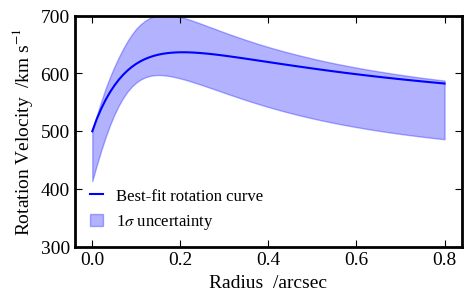

In [21]:
### rotation curve with error band ###
# サンプルから rotation curve を計算
from tqdm import tqdm
from glint.source import Vrot_Courteau1997
n_samples = flat_chain.shape[0]
radius_rc = np.arange(0, 0.8+1e-6, 0.01) # 0含める

# 5個おきのサンプルだけ使う
idx = np.arange(0, n_samples, 5)

vrot_samples = []
for i in tqdm(range(0, n_samples, 5)):
    params = flat_chain[i]
    v_c = params[6]
    r_turn = params[7]
    gamma_curve = params[8]
    vrot_samples.append(Vrot_Courteau1997(r=radius_rc, v_c=v_c, r_turn=r_turn, gamma=gamma_curve, beta=1.0))
vrot_samples = np.array(vrot_samples)
vrot_median = np.median(vrot_samples, axis=0)
vrot_16 = np.percentile(vrot_samples, 16, axis=0)
vrot_84 = np.percentile(vrot_samples, 84, axis=0)   

fig, ax = plt.subplots(figsize=(5,3))
ax.plot(radius_rc, vrot_median, color='blue', label='Best-fit rotation curve')
ax.fill_between(radius_rc, vrot_16, vrot_84, color='blue', alpha=0.3, label='1$\sigma$ uncertainty')
ax.set_xlabel('Radius  /arcsec', fontsize=14)
ax.set_ylabel(r'Rotation Velocity  /km s$^{-1}$', fontsize=14)
ax.legend(fontsize=12)
ax.set_ylim(300, 700)
fig.savefig("./figure/rotation_curve_G09_lens_fix.pdf", dpi=200, bbox_inches="tight")
print("Saved to ./figure/rotation_curve_G09_lens_fix.pdf")
plt.show()

## Compare models and observations

Saved to ./figure/channel_maps_G09_lens_fix.pdf


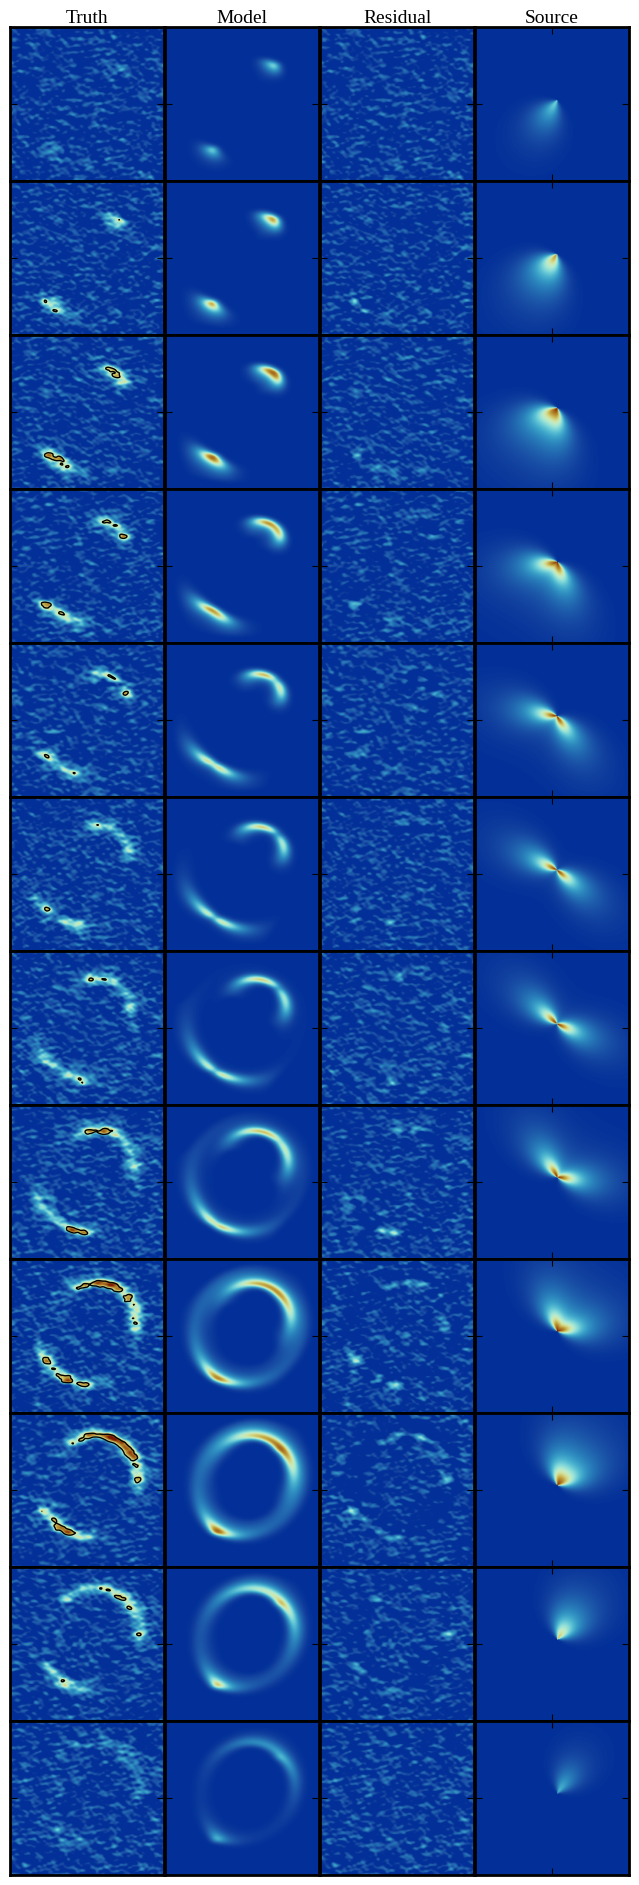

In [20]:
# model with best-fit parameters
best_source, best_lensed_cube, best_lensed_cube_conv = forward_model_3D_image(best_theta, ctx)

# Plot cube for each channel
# Some settings for plotting
vmax = np.nanmax(obsdata) * 0.9
width = 2
titles = ["Truth", "Model", "Residual", "Source"]


fig, axes = plt.subplots(nchan, ncols=4, figsize=(width*4, width*nchan))
fig.subplots_adjust(wspace=0., hspace=0.0)
for i in range(nchan):
    im0 = axes[i, 0].imshow(obsdata[i], cmap=cm.roma_r, origin="lower", vmin=0, vmax=vmax)
    axes[i, 0].contour(obsdata[i]/noisedata[i], levels=[8,16,32], colors='black', linewidths=1.0)
    im1 = axes[i, 1].imshow(best_lensed_cube_conv[i], cmap=cm.roma_r, origin="lower", vmin=0, vmax=vmax)
    # im2 = axes[i, 2].imshow((obsdata[i] - best_lensed_cube_conv[i]) / noisedata[i], cmap=cm.roma_r, origin="lower", vmin=-3, vmax=3)
    im2 = axes[i, 2].imshow((obsdata[i] - best_lensed_cube_conv[i]), cmap=cm.roma_r, origin="lower", vmin=0, vmax=vmax)
    im3 = axes[i, 3].imshow(best_source[i], cmap=cm.roma_r, origin="lower", vmin=0, vmax=np.nanmax(best_source))

    if i==0:
        for j in range(4):
            axes[i, j].set_title(titles[j], fontsize=14, pad=-2)
    for j in range(4):
        # divider = make_axes_locatable(axes[i,j])
        # cax = divider.append_axes("right", size="5%", pad=0.)
        # fig.colorbar([im0, im1, im2, im3][j], cax=cax)
        axes[i, j].set_xticklabels([])
        axes[i, j].set_yticklabels([])

    
fig.savefig("./figure/channel_maps_G09_lens_fix.pdf", dpi=200, bbox_inches="tight")
print("Saved to ./figure/channel_maps_G09_lens_fix.pdf")
# plt.tight_layout()